--- Data Snapshot ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520




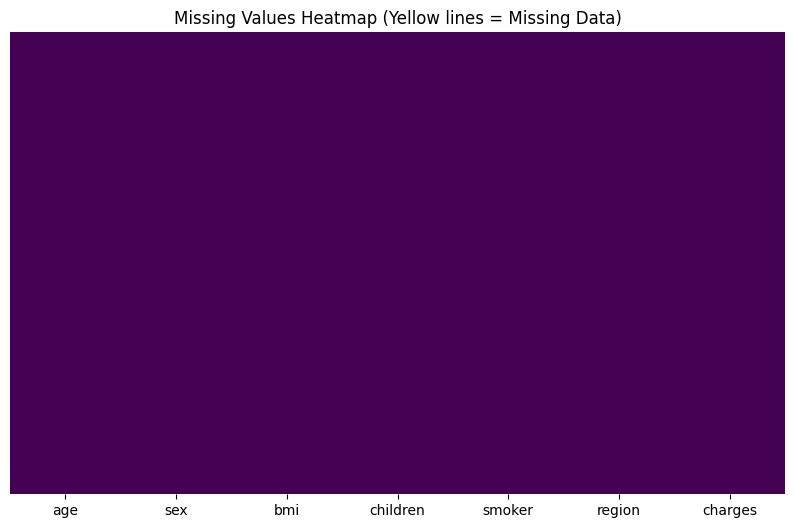

--- Missing Values Count ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


--- Data After Encoding (Text -> Numbers) ---
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


...Model Trained Successfully...

--- Model Performance ---
Model Accuracy (R^2 Sco

In [3]:
# ==========================================
# STEP 1: LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import os

# ==========================================
# STEP 2: LOAD DATA
# ==========================================
path = 'insurance.csv'

if not os.path.exists(path):
    print(f"ERROR: Could not find {path}")
    print("Please ensure insurance.csv is in the same directory as this notebook.")
else:
    df = pd.read_csv(path)

    print("--- Data Snapshot ---")
    print(df.head())
    print("\n")

    # ==========================================
    # STEP 3: VISUALIZING MISSING VALUES
    # ==========================================
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap (Yellow lines = Missing Data)')
    plt.savefig('missing_values_heatmap.png')
    plt.show()

    print("--- Missing Values Count ---")
    print(df.isnull().sum())
    print("\n")

    # ==========================================
    # STEP 4: DATA PREPROCESSING (One-Hot Encoding)
    # ==========================================
    categorical_columns = ['sex', 'smoker', 'region']
    df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

    print("--- Data After Encoding (Text -> Numbers) ---")
    print(df_encoded.head())
    print("\n")

    # ==========================================
    # STEP 5: SPLITTING THE DATA
    # ==========================================
    X = df_encoded.drop('charges', axis=1)
    y = df_encoded['charges']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ==========================================
    # STEP 6: BUILD & TRAIN MODEL
    # ==========================================
    model = LinearRegression()
    model.fit(X_train, y_train)

    print("...Model Trained Successfully...\n")

    # ==========================================
    # STEP 7: EVALUATION
    # ==========================================
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)

    print("--- Model Performance ---")
    print(f"Model Accuracy (R^2 Score): {r2:.2f}")

    # ==========================================
    # STEP 8: EXPORT MODEL FOR DEPLOYMENT
    # ==========================================
    models_dir = '../models'
    os.makedirs(models_dir, exist_ok=True)

    joblib.dump(model, os.path.join(models_dir, 'insurance_model.pkl'))
    print(f"\n✓ Model saved to {models_dir}/insurance_model.pkl")

    joblib.dump(X.columns.tolist(), os.path.join(models_dir, 'model_columns.pkl'))
    print(f"✓ Model columns saved to {models_dir}/model_columns.pkl")

    print("\n✓ Model files are ready for Streamlit deployment!")
